# Predicting house prices using different machine learning techniques

The datasets are from Kaggle. These contain various features and attributes of residential homes in Ames, Iowa, USA. 

Here are some key details about the Ames Housing Dataset:

Number of Instances: The dataset consists of 1460 instances or observations in the train dataset and the same number in the test dataset.
Number of Features: There are 79 different features or variables that describe various aspects of the residential properties.
Target Variable: The target variable in the dataset is the "SalePrice," representing the sale price of the houses.
Data Types: The features include both numerical and categorical variables, covering a wide range of aspects such as lot size, number of rooms, location, construction, and more.

### Importing the data

In [1]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')
y_test = sample['SalePrice']
train.head().T

,0,1,2,3,4
Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450,9600,11250,9550,14260
...,...,...,...,...,...
MoSold,2,5,9,2,12
YrSold,2008,2007,2008,2006,2008
SaleType,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Normal,Abnorml,Normal


### I will use the train dataset to build and test the models, and the test dataset is for compering with others' solution. In the sample dataset I can see the benchmark.

## Data exploration

### Train dataset

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

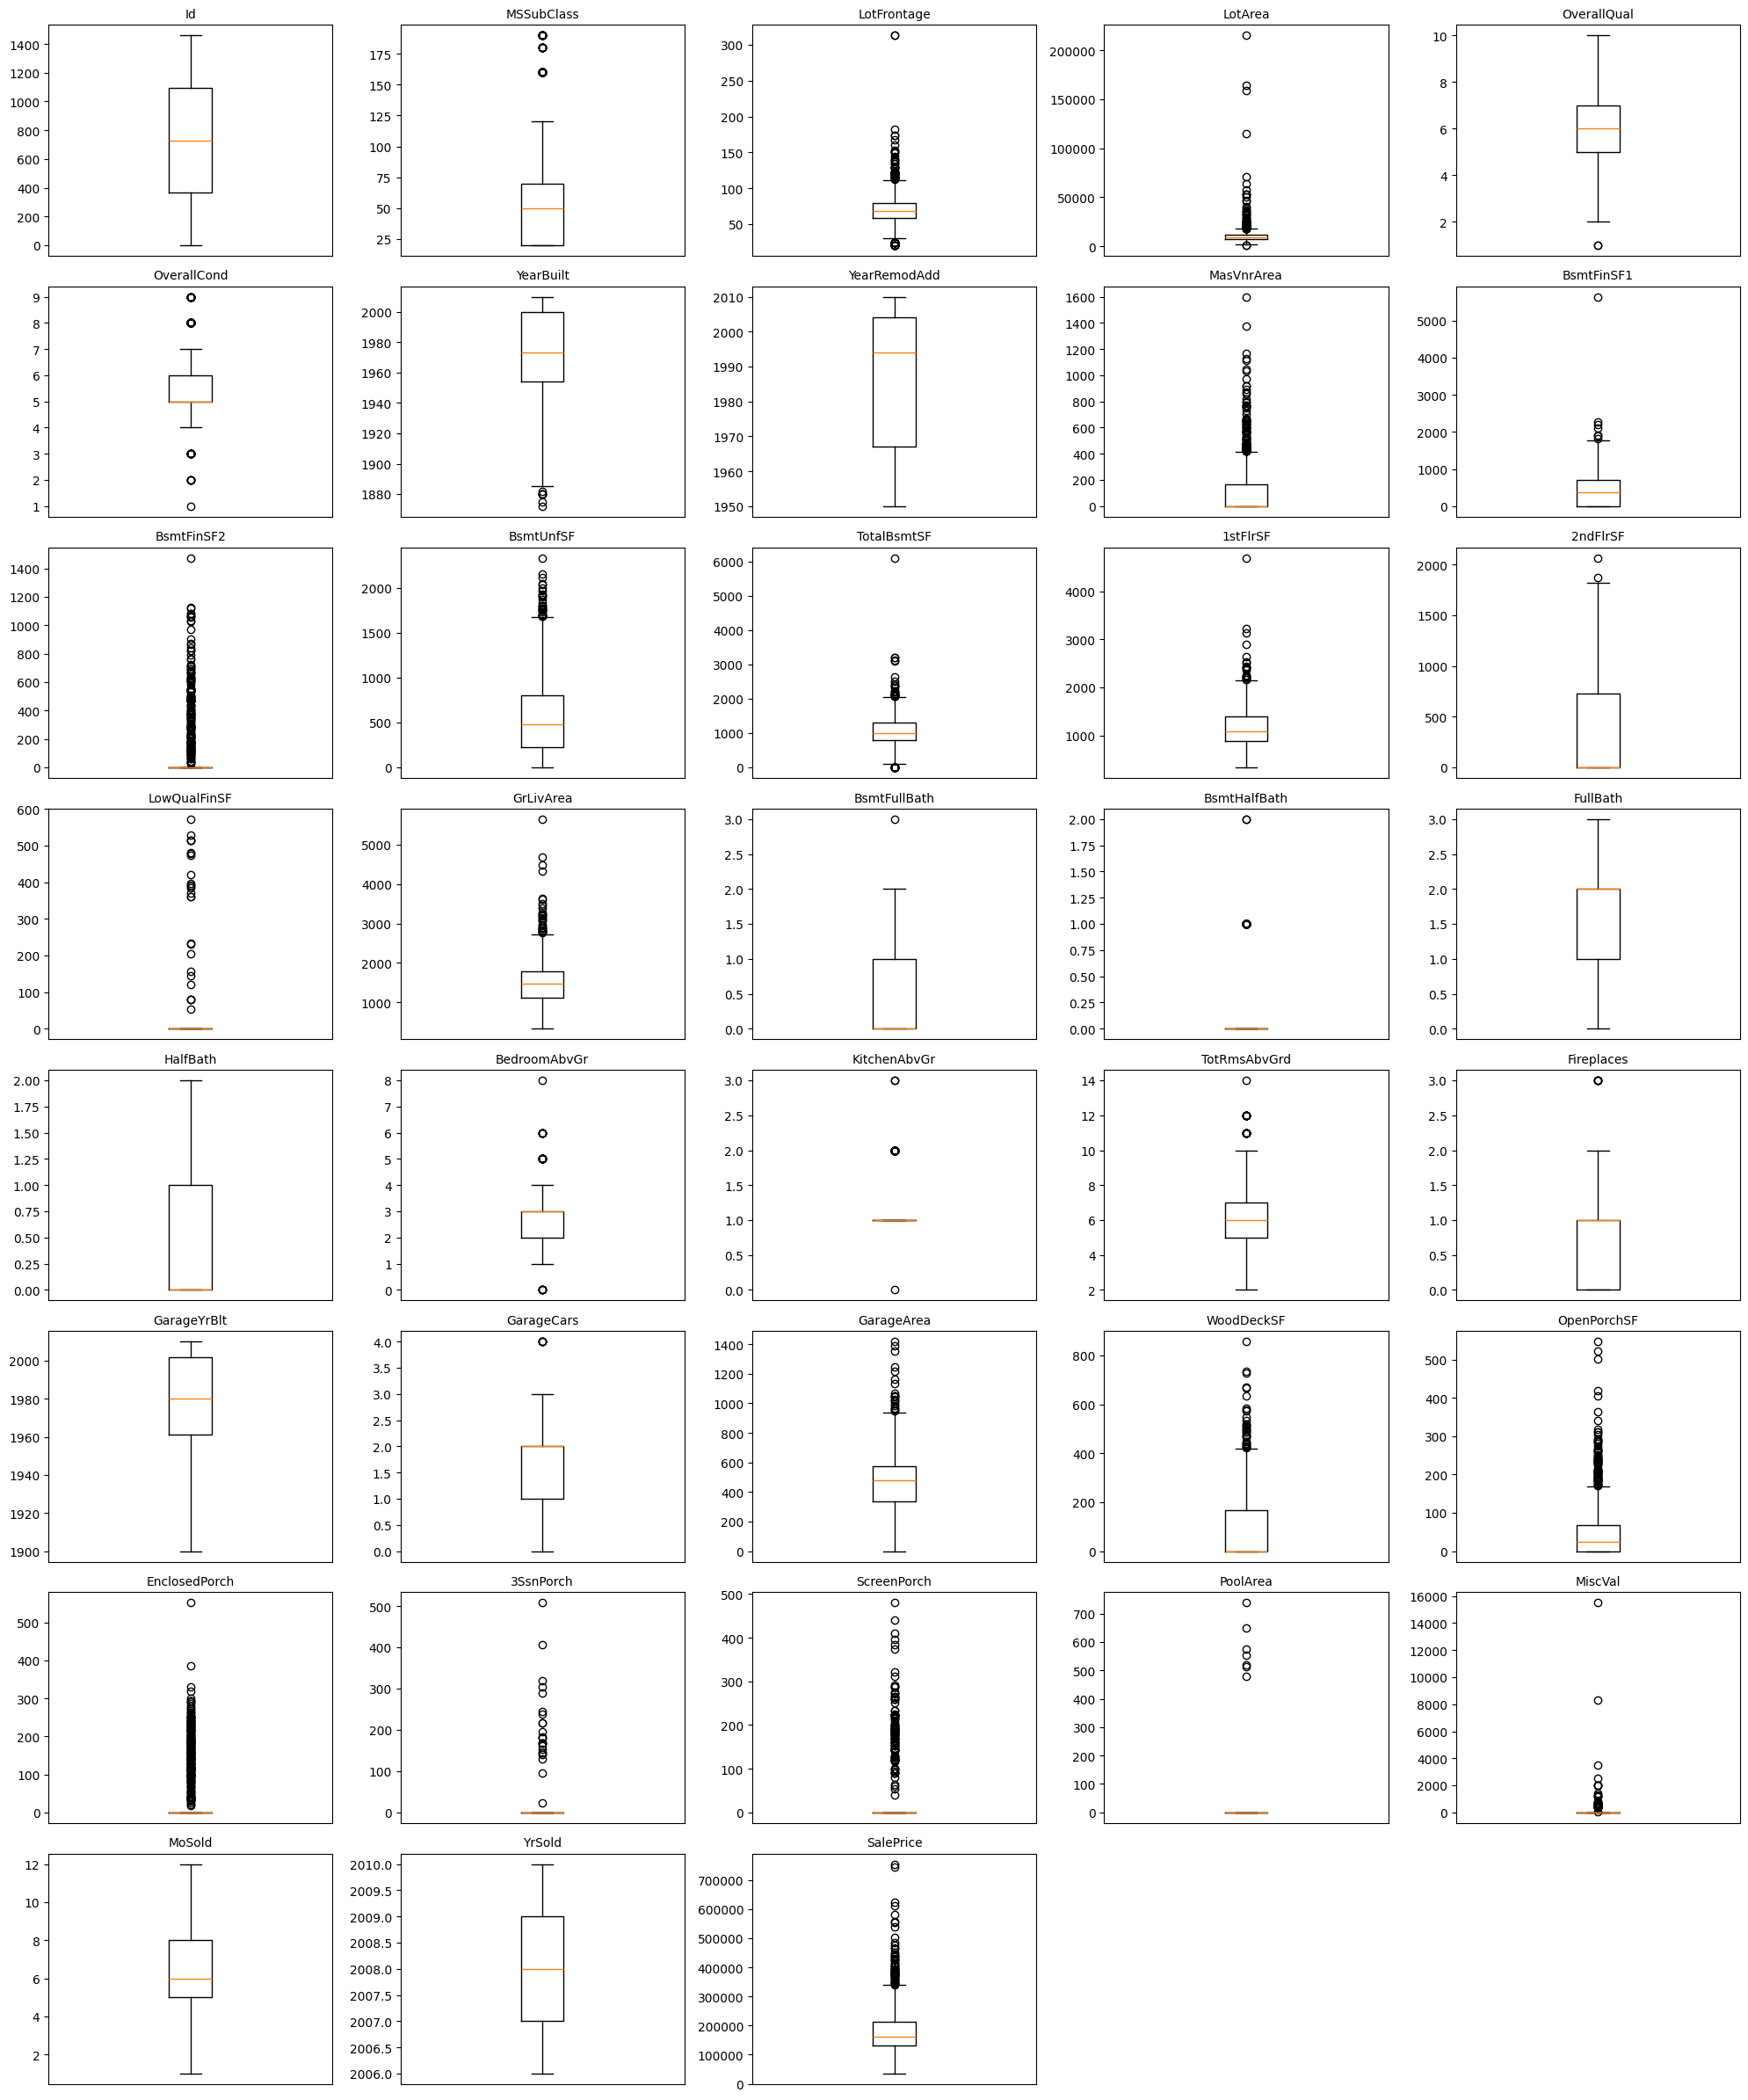

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# numeric columns in the train dataframe
numeric_cols = train.select_dtypes(include='number').columns
n = len(numeric_cols)

# Grid layout settings (40 plots → 8 rows × 5 cols works well)
grid_cols = 5
grid_rows = int(np.ceil(n / grid_cols))

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols*4, grid_rows*3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(train[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### Here we can see the different distribution of the numeric variables, boxplot also shows the outliers as well, in most cases we have, so I need to handle it by standardization.

In [4]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Test dataset

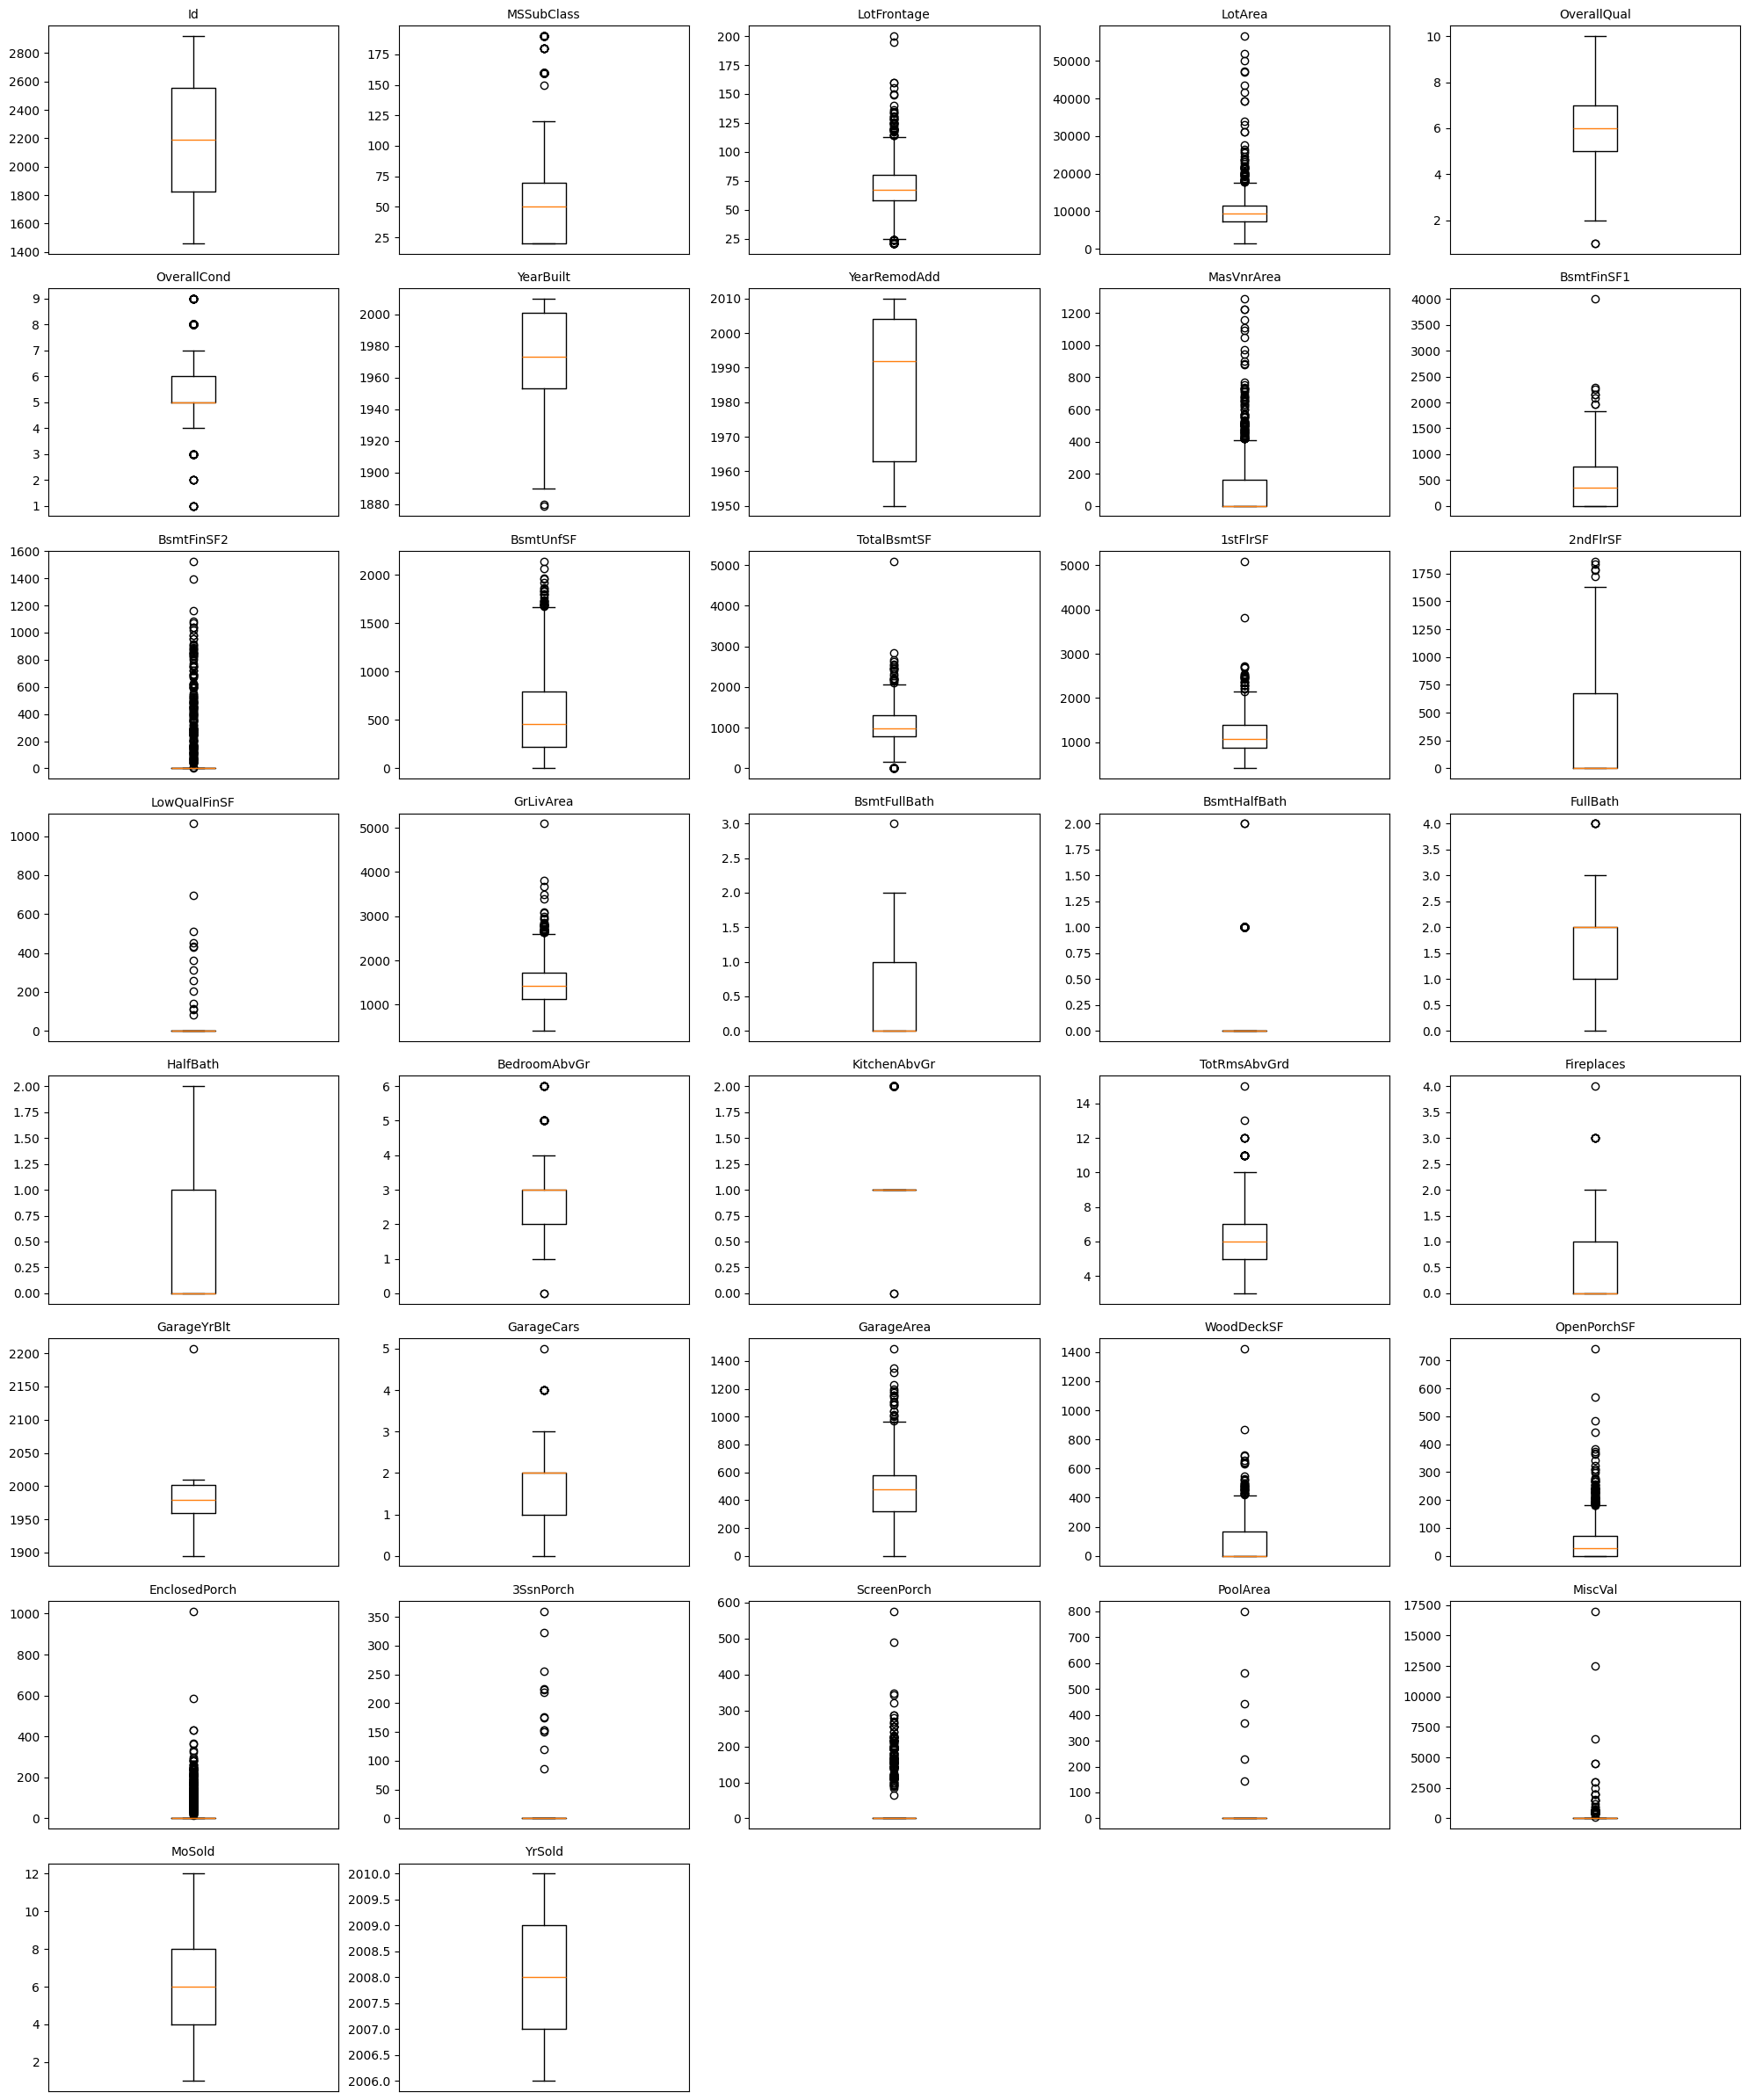

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# numeric columns in the train dataframe
numeric_cols = test.select_dtypes(include='number').columns
n = len(numeric_cols)

# Grid layout settings (40 plots → 8 rows × 5 cols works well)
grid_cols = 5
grid_rows = int(np.ceil(n / grid_cols))

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols*4, grid_rows*3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(test[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### The test dataset shows similar distributions.

In [6]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1459.0,2190.000000,421.321334,1461.0,1825.50,2190.0,2554.50,2919.0
MSSubClass,1459.0,57.378341,42.746880,20.0,20.00,50.0,70.00,190.0
LotFrontage,1232.0,68.580357,22.376841,21.0,58.00,67.0,80.00,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.00,9399.0,11517.50,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.00,6.0,7.00,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.00,5.0,6.00,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.00,1973.0,2001.00,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.00,1992.0,2004.00,2010.0
MasVnrArea,1444.0,100.709141,177.625900,0.0,0.00,0.0,164.00,1290.0
BsmtFinSF1,1458.0,439.203704,455.268042,0.0,0.00,350.5,753.50,4010.0


## Handling missing values

In [7]:
train.isnull().sum()[train.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [8]:
cols_with_missing = [col for col in train.columns if train[col].isnull().any()]
cols_with_missing

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [9]:
missing_stats = train[cols_with_missing].isna().agg(['sum', 'mean']).T
missing_stats.columns = ['missing_count', 'missing_percent']
missing_stats = missing_stats.sort_values(by='missing_percent', ascending=False)
print(missing_stats)

              missing_count  missing_percent
PoolQC               1453.0         0.995205
MiscFeature          1406.0         0.963014
Alley                1369.0         0.937671
Fence                1179.0         0.807534
MasVnrType            872.0         0.597260
FireplaceQu           690.0         0.472603
LotFrontage           259.0         0.177397
GarageType             81.0         0.055479
GarageYrBlt            81.0         0.055479
GarageFinish           81.0         0.055479
GarageQual             81.0         0.055479
GarageCond             81.0         0.055479
BsmtFinType2           38.0         0.026027
BsmtExposure           38.0         0.026027
BsmtFinType1           37.0         0.025342
BsmtCond               37.0         0.025342
BsmtQual               37.0         0.025342
MasVnrArea              8.0         0.005479
Electrical              1.0         0.000685


### We can see that we have 19 columns containing missing values. I handle each case separately for imputing meaningful data. In some cases I assume missingness means having no such a feature like pool or fence. 

In [10]:
train['PoolQC'].fillna('No Pool', inplace=True)


In [11]:
train['MiscFeature'].value_counts()

MiscFeature
Shed    49
Gar2     2
Othr     2
TenC     1
Name: count, dtype: int64

In [12]:
train["MiscFeature"].fillna("None", inplace=True) 


In [13]:
train["Alley"].fillna("No Alley access", inplace=True)

In [14]:
train["Fence"].fillna("No Fence", inplace=True)


In [15]:
train['MasVnrType'].fillna('None', inplace=True)


In [16]:
train["FireplaceQu"].fillna("No Fireplace", inplace=True)


In [17]:
train['LotFrontage'].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
137.0      1
141.0      1
38.0       1
140.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [18]:

#in case of LotFrontage, I would not fill with 0 because the NA rather means not given value
#so I will impute by the median LotFrontage of the neighborhood
train["LotFrontage"] = train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)


In [19]:
train["GarageType"].fillna("No Garage", inplace=True)


In [20]:
train["GarageYrBlt"].value_counts()
#I will fill the missing values with 0, meaning no garage
train["GarageYrBlt"].fillna(0, inplace=True)


In [21]:
train["GarageQual"].fillna("No Garage", inplace=True)
train["GarageCond"].fillna("No Garage", inplace=True)
train["GarageFinish"].fillna("No Garage", inplace=True)


In [22]:
train['BsmtCond'].fillna('No Basement', inplace=True)
train['BsmtQual'].fillna('No Basement', inplace=True)
train['BsmtExposure'].fillna('No Basement', inplace=True)



In [23]:
train['BsmtFinType1'].value_counts()
train["BsmtFinType1"].fillna("None", inplace=True)


In [24]:
train['BsmtFinType2'].value_counts()

train["BsmtFinType2"].fillna("None", inplace=True)


In [25]:
train['MasVnrArea'].value_counts()
#I will fill the missing values with 0, meaning no masonry veneer area
train['MasVnrArea'].fillna(0, inplace=True)

In [26]:
train["Electrical"].value_counts()
#missing value does not make sense, I will fill with the mode
train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)


In [27]:
cols_with_missing = [col for col in train.columns if train[col].isnull().any()]
cols_with_missing

[]

### Now I do not have any missing value, lets do the same with the test dataset.

In [28]:
test['PoolQC'].fillna('No Pool', inplace=True)
test["MiscFeature"].fillna("None", inplace=True)
test["Alley"].fillna("No Alley access", inplace=True)
test["Fence"].fillna("No Fence", inplace=True)
test['MasVnrType'].fillna('None', inplace=True)
test["FireplaceQu"].fillna("No Fireplace", inplace=True)
test["LotFrontage"] = test.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)
test["GarageType"].fillna("No Garage", inplace=True)
test["GarageYrBlt"].fillna(0, inplace=True)
test["GarageQual"].fillna("No Garage", inplace=True)
test["GarageCond"].fillna("No Garage", inplace=True)
test["GarageFinish"].fillna("No Garage", inplace=True)
test['BsmtCond'].fillna('No Basement', inplace=True)
test['BsmtQual'].fillna('No Basement', inplace=True)
test['BsmtExposure'].fillna('No Basement', inplace=True)
test["BsmtFinType1"].fillna("None", inplace=True)
test["BsmtFinType2"].fillna("None", inplace=True)
test['MasVnrArea'].fillna(0, inplace=True)
test['Electrical'].fillna(test['Electrical'].mode()[0], inplace=True)

### Lets see if there is more missing values in the test dataset.

In [29]:
test.isnull().sum()[test.isnull().sum()>0]

MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
KitchenQual     1
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

### We have, so lets handle these as well. In case of numeric columns, I use the median, in case of categorical columns I use the mode.

In [30]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
numerical_cols = test.select_dtypes(include=['int64', 'float64']).columns
test[numerical_cols] = num_imputer.fit_transform(test[numerical_cols])
cat_cols = test.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy="most_frequent")
test[cat_cols] = cat_imputer.fit_transform(test[cat_cols])

### Lets split the datasets.

#### I use log transformation of the target variable, because it is not normally distributed, and it would be benefitial for the linear regression. For decision tree and light gbm it is not necessary but it would not hurt our result neither.

In [31]:
from sklearn.model_selection import train_test_split
# Separate features and target
# Log transform target variable for better normality
y = np.log1p(train['SalePrice'])
X = train.drop(['SalePrice', 'Id'], axis=1)
X_test = test.drop('Id', axis=1)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Detect column types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

#### I will use scaler to normalize the numerical features. I will fit the scaler only on the training data. For the categorical features, I will use one hot encoding.

#### Function for residuals plot

In [32]:
def plot_residuals(y_true, y_pred, title):
    """Generates a residual plot to diagnose model performance."""
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Values (log scale)')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot: {title}')
    plt.grid(True)
    plt.show()

#### Function for evaluation

In [33]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
#code for evaluation metrics 
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model", plot_residuals_flag=True):
    """Evaluate model with multiple metrics"""
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Cross-validation RMSE
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    if plot_residuals_flag:
        print(f"\n--- Residual Plots for {model_name} ---")
        # Plot for training set
        plot_residuals(y_train, y_train_pred, f"{model_name} (Training Set)")
        # Plot for validation set
        plot_residuals(y_val, y_val_pred, f"{model_name} (Validation Set)")
    
    
    # Return metrics
    return {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'cv_rmse': cv_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'train_r2': train_r2,
        'val_r2': val_r2

    }



## Building linear regression


--- Residual Plots for Linear Regression ---


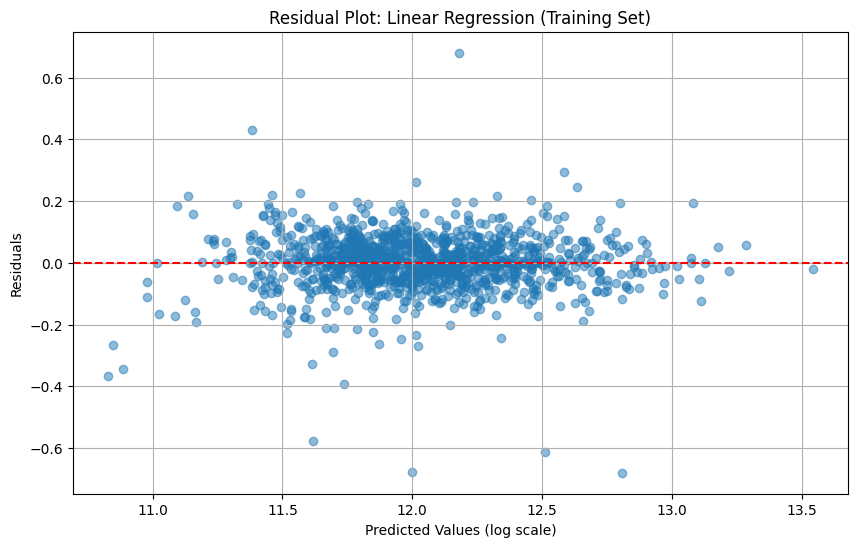

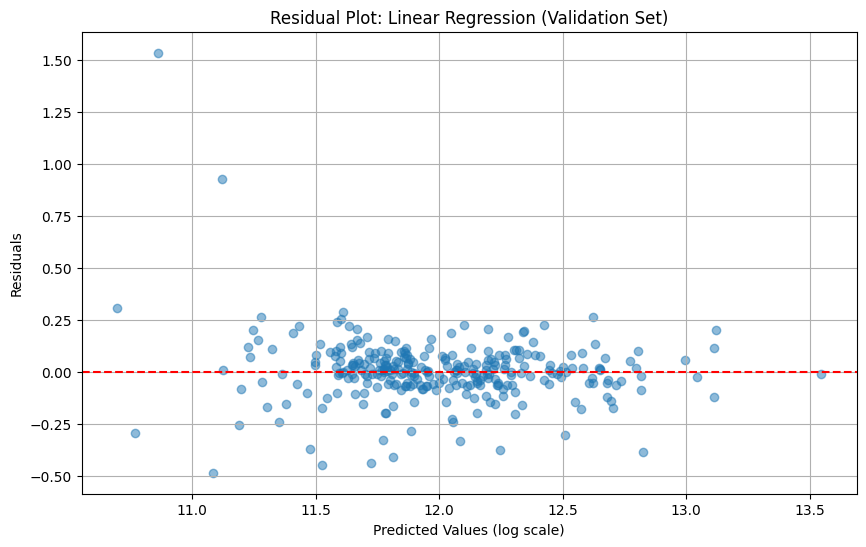

Linear Regression Metrics:
Train RMSE: 0.0917
Validation RMSE: 0.1623
CV RMSE: 0.1788
Train MAE: 0.0630
Validation MAE: 0.0954
Train R²: 0.9448
Validation R²: 0.8588


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression


num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_metrics = evaluate_model(lr_model, X_train, y_train, X_val, y_val,"Linear Regression", plot_residuals_flag=True)
print("Linear Regression Metrics:")
print(f"Train RMSE: {lr_metrics['train_rmse']:.4f}")
print(f"Validation RMSE: {lr_metrics['val_rmse']:.4f}")
print(f"CV RMSE: {lr_metrics['cv_rmse']:.4f}")
print(f"Train MAE: {lr_metrics['train_mae']:.4f}")
print(f"Validation MAE: {lr_metrics['val_mae']:.4f}")
print(f"Train R²: {lr_metrics['train_r2']:.4f}")
print(f"Validation R²: {lr_metrics['val_r2']:.4f}")







## Now I would like to build a linear regression with lasso, so I would try not to use all the variables.

/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 14, 15, 16, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 13, 14, 27, 31] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10, 15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 14, 15, 16, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.


--- Residual Plots for Lasso Regression ---


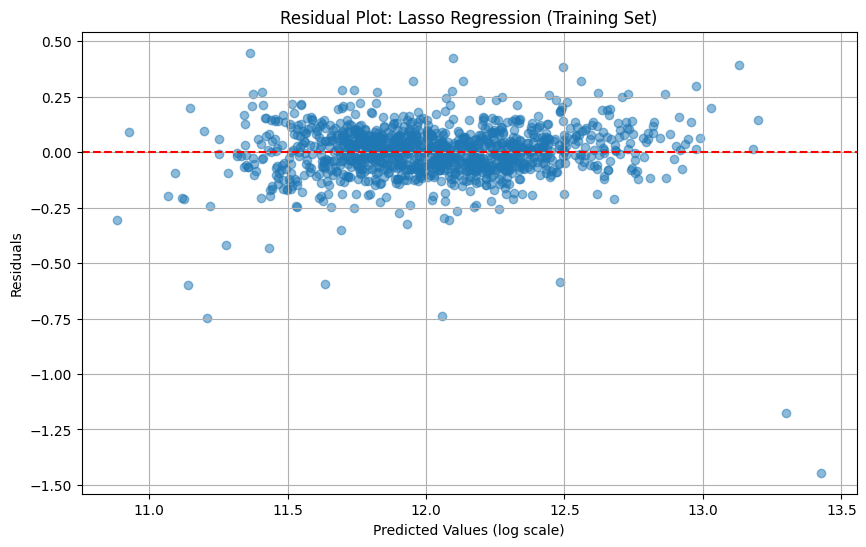

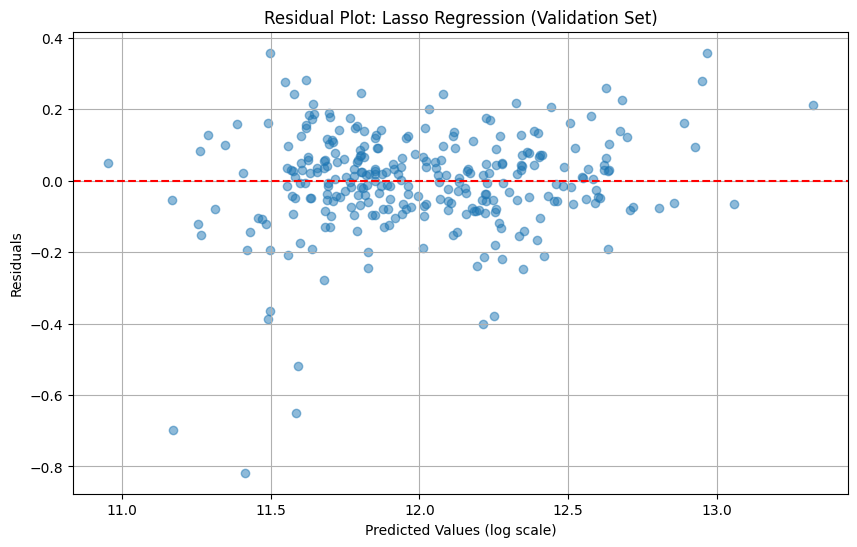


Lasso Regression Metrics:
Best Alpha: 0.001
Train RMSE: 0.1234
Validation RMSE: 0.1428
CV RMSE: 0.1490
Train MAE: 0.0827
Validation MAE: 0.0994
Train R²: 0.9001
Validation R²: 0.8908


In [35]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=5000))
])

param_grid = {'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

lasso_grid = GridSearchCV(lasso_model, param_grid, cv=5, 
                          scoring='neg_root_mean_squared_error', n_jobs=-1)

lasso_grid.fit(X_train, y_train)

# Get best model
best_lasso = lasso_grid.best_estimator_

# Evaluate best model
lasso_metrics = evaluate_model(best_lasso, X_train, y_train, X_val, y_val, "Lasso Regression", plot_residuals_flag=True)
print("\nLasso Regression Metrics:")
print(f"Best Alpha: {lasso_grid.best_params_['regressor__alpha']}")
print(f"Train RMSE: {lasso_metrics['train_rmse']:.4f}")
print(f"Validation RMSE: {lasso_metrics['val_rmse']:.4f}")
print(f"CV RMSE: {lasso_metrics['cv_rmse']:.4f}")
print(f"Train MAE: {lasso_metrics['train_mae']:.4f}")
print(f"Validation MAE: {lasso_metrics['val_mae']:.4f}")
print(f"Train R²: {lasso_metrics['train_r2']:.4f}")
print(f"Validation R²: {lasso_metrics['val_r2']:.4f}")

### Feature importance for lasso regression

In [36]:


feature_names = lasso_grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
coefficients = lasso_grid.best_estimator_.named_steps["regressor"].coef_

import pandas as pd
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

significant_features = coef_df[round(coef_df["coefficient"],2) != 0.00].sort_values(by="coefficient", key=abs, ascending=False)
print("Significant features:\n", significant_features)

Significant features:
                        feature  coefficient
15              num__GrLivArea     0.102607
77   cat__Neighborhood_StoneBr     0.094012
71   cat__Neighborhood_NridgHt     0.091385
3             num__OverallQual     0.090717
61   cat__Neighborhood_Crawfor     0.084687
..                         ...          ...
106       cat__RoofStyle_Gable    -0.006383
29          num__EnclosedPorch     0.006197
232          cat__PavedDrive_Y     0.005576
48        cat__LandContour_Lvl     0.005448
35                 num__YrSold    -0.005217

[66 rows x 2 columns]


## Decision Tree model


--- Residual Plots for Decision Tree ---


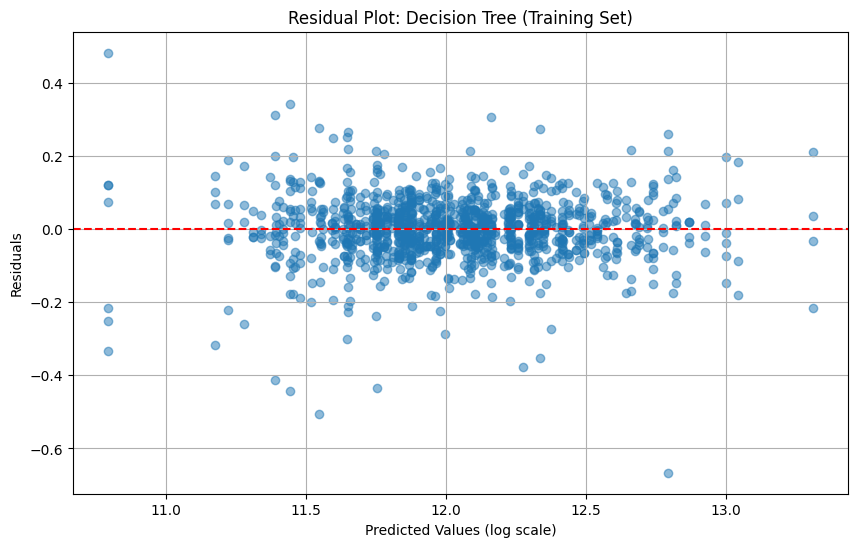

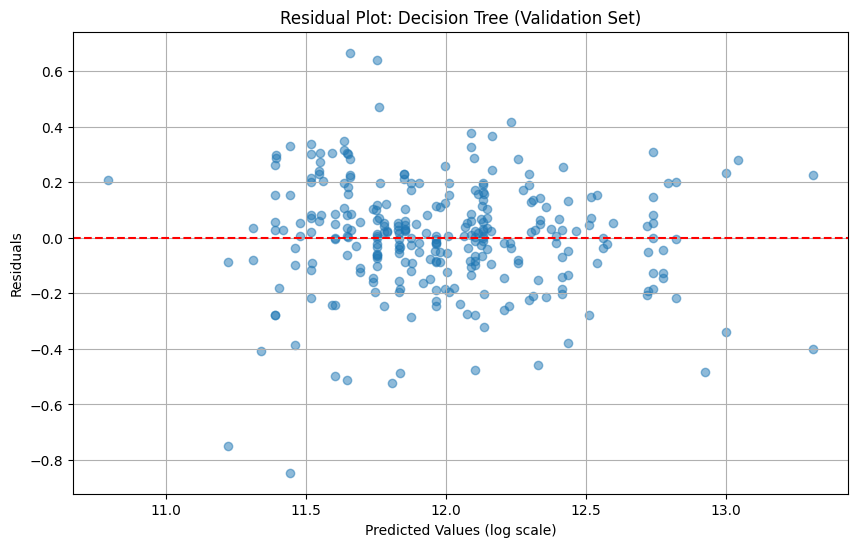


Decision Tree Metrics:
Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2}
Train RMSE: 0.0878
Validation RMSE: 0.1973
CV RMSE: 0.1932
Train MAE: 0.0611
Validation MAE: 0.1445
Train R²: 0.9495
Validation R²: 0.7913


In [37]:
from sklearn.tree import DecisionTreeRegressor

# -----------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols) # here I do not drop first to allow tree to use all categories
    ]
)
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {
    'regressor__max_depth': [None, 5, 10, 15, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt_model, param_grid_dt, cv=5, 
                       scoring='neg_root_mean_squared_error', n_jobs=-1)

dt_grid.fit(X_train, y_train)

# Get best model
best_dt = dt_grid.best_estimator_

# Evaluate best model
dt_metrics = evaluate_model(best_dt, X_train, y_train, X_val, y_val, "Decision Tree", plot_residuals_flag=True)
print("\nDecision Tree Metrics:")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Train RMSE: {dt_metrics['train_rmse']:.4f}")
print(f"Validation RMSE: {dt_metrics['val_rmse']:.4f}")
print(f"CV RMSE: {dt_metrics['cv_rmse']:.4f}")
print(f"Train MAE: {dt_metrics['train_mae']:.4f}")
print(f"Validation MAE: {dt_metrics['val_mae']:.4f}")
print(f"Train R²: {dt_metrics['train_r2']:.4f}")
print(f"Validation R²: {dt_metrics['val_r2']:.4f}")



## Now lets check the random forest


--- Residual Plots for Random Forest ---


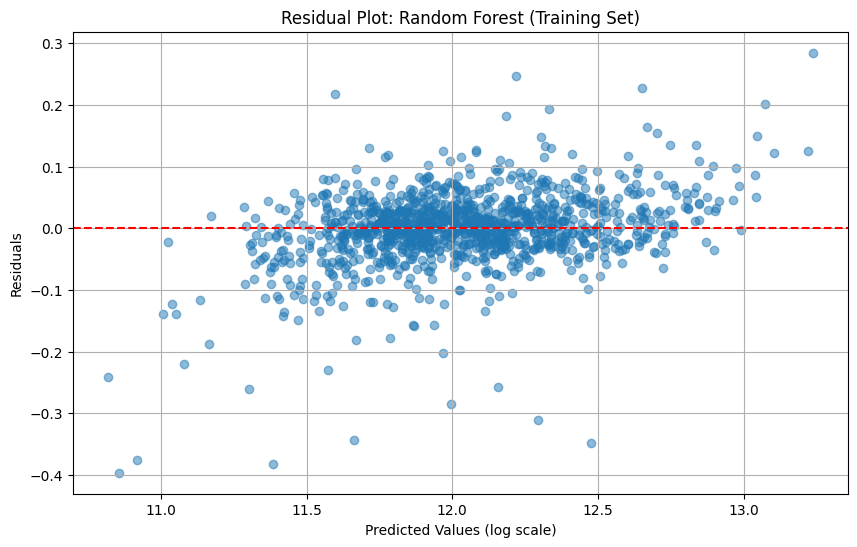

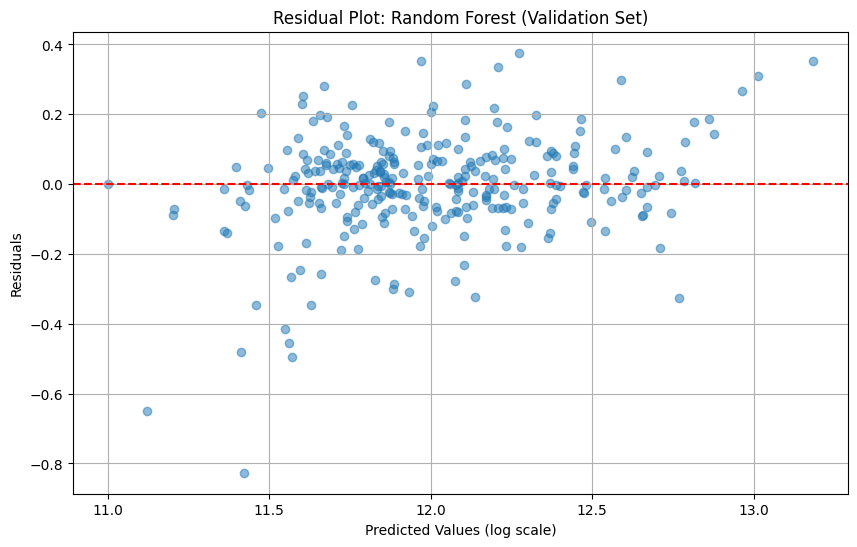


Random Forest Metrics:
Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}
Train RMSE: 0.0601
Validation RMSE: 0.1457
CV RMSE: 0.1440
Train MAE: 0.0399
Validation MAE: 0.0987
Train R²: 0.9763
Validation R²: 0.8862


In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_model, param_grid, cv=5, 
                      scoring='neg_root_mean_squared_error', n_jobs=-1)

rf_grid.fit(X_train, y_train)

# Get best model
best_rf = rf_grid.best_estimator_

# Evaluate best model
rf_metrics = evaluate_model(best_rf, X_train, y_train, X_val, y_val, "Random Forest", plot_residuals_flag=True)
print("\nRandom Forest Metrics:")
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Train RMSE: {rf_metrics['train_rmse']:.4f}")
print(f"Validation RMSE: {rf_metrics['val_rmse']:.4f}")
print(f"CV RMSE: {rf_metrics['cv_rmse']:.4f}")
print(f"Train MAE: {rf_metrics['train_mae']:.4f}")
print(f"Validation MAE: {rf_metrics['val_mae']:.4f}")
print(f"Train R²: {rf_metrics['train_r2']:.4f}")
print(f"Validation R²: {rf_metrics['val_r2']:.4f}")


In [39]:
#pip install lightgbm

## Lets build a gradient boosting model

/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/livi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur


--- Residual Plots for LightGBM ---


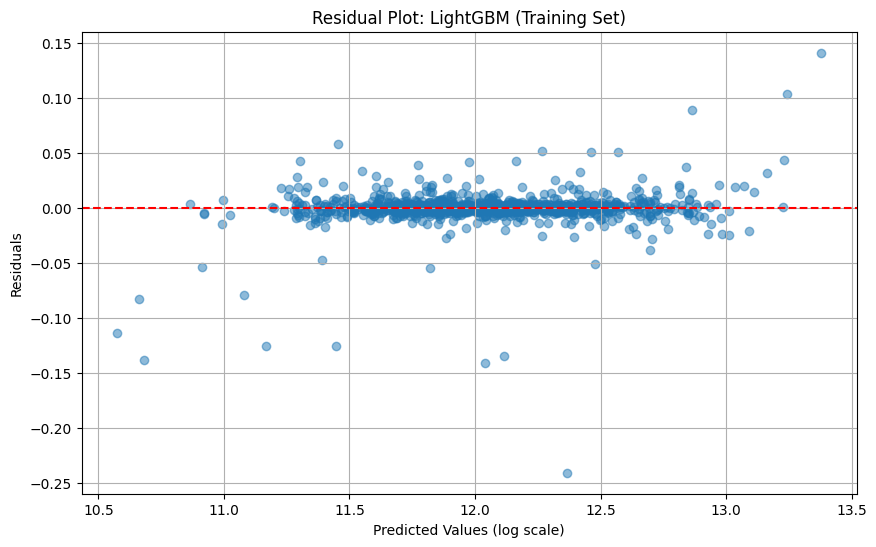

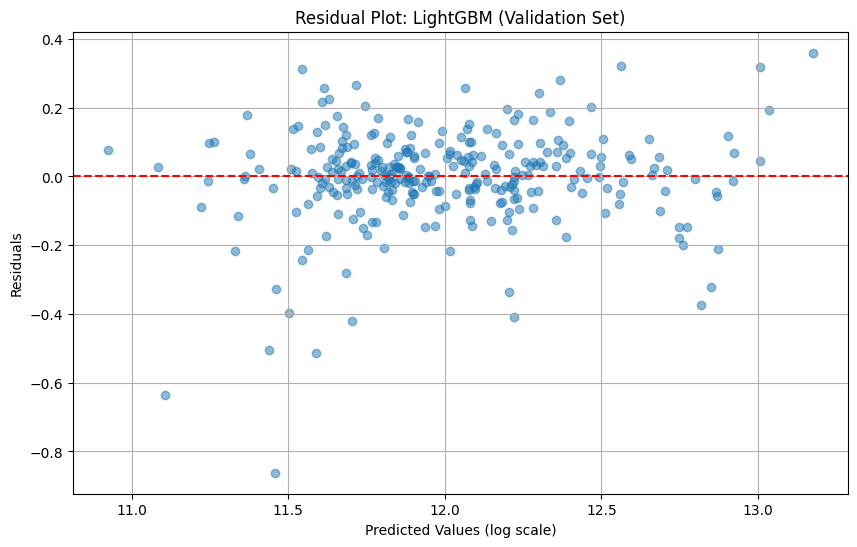


LightGBM Metrics:
Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__n_estimators': 500, 'regressor__num_leaves': 50}
Train RMSE: 0.0159
Validation RMSE: 0.1392
CV RMSE: 0.1340
Train MAE: 0.0060
Validation MAE: 0.0914
Train R²: 0.9983
Validation R²: 0.8962


In [40]:

import lightgbm as lgb
lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(random_state=42, verbose=-1))
])

param_grid = {
    'regressor__n_estimators': [500, 1000],
    'regressor__learning_rate': [0.01, 0.05],
    'regressor__num_leaves': [31, 50]
}

lgbm_grid = GridSearchCV(lgbm_model, param_grid, cv=5, 
                        scoring='neg_root_mean_squared_error', n_jobs=-1)

lgbm_grid.fit(X_train, y_train)

# Get best model
best_lgbm = lgbm_grid.best_estimator_

# Evaluate best model
lgbm_metrics = evaluate_model(best_lgbm, X_train, y_train, X_val, y_val ,"LightGBM", plot_residuals_flag=True)
print("\nLightGBM Metrics:")
print(f"Best Parameters: {lgbm_grid.best_params_}")
print(f"Train RMSE: {lgbm_metrics['train_rmse']:.4f}")
print(f"Validation RMSE: {lgbm_metrics['val_rmse']:.4f}")
print(f"CV RMSE: {lgbm_metrics['cv_rmse']:.4f}")
print(f"Train MAE: {lgbm_metrics['train_mae']:.4f}")
print(f"Validation MAE: {lgbm_metrics['val_mae']:.4f}")
print(f"Train R²: {lgbm_metrics['train_r2']:.4f}")
print(f"Validation R²: {lgbm_metrics['val_r2']:.4f}")

#

### Feature importance

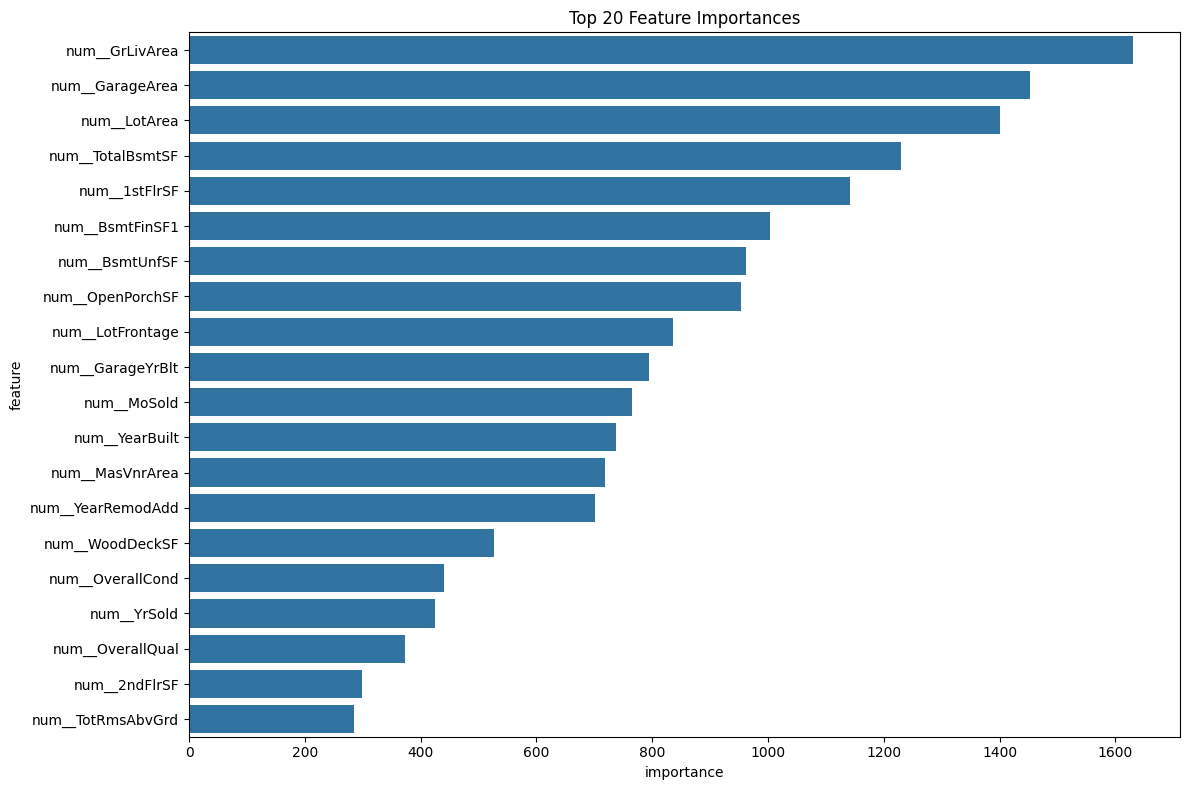

In [42]:
import seaborn as sns

feature_names = best_lgbm.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from the best model
importances = best_lgbm.named_steps['regressor'].feature_importances_

# Create dataframe of feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

### Lets compare the models


Model Comparison:
                   train_rmse  val_rmse   cv_rmse    val_r2
Linear Regression    0.091704  0.162306  0.178799  0.858833
Lasso Regression     0.123389  0.142757  0.148965  0.890791
Decision Tree        0.087766  0.197327  0.193171  0.791341
Random Forest        0.060084  0.145731  0.144040  0.886194
LightGBM             0.015875  0.139178  0.133998  0.896199


<Figure size 1200x600 with 0 Axes>

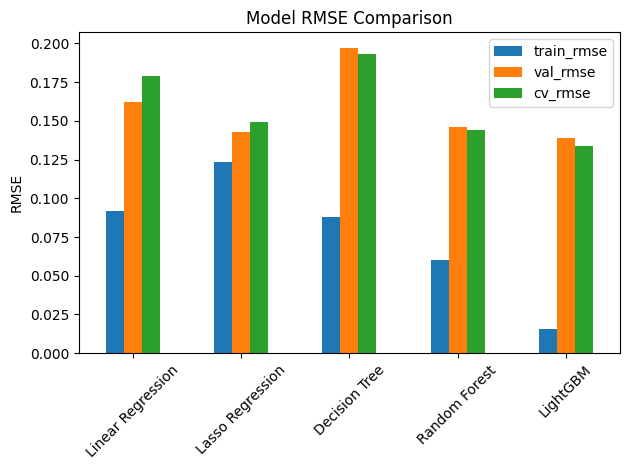

In [43]:

models_metrics = {
    'Linear Regression': lr_metrics,
    'Lasso Regression': lasso_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'LightGBM': lgbm_metrics
}

# Create comparison dataframe
comparison_df = pd.DataFrame(models_metrics).T
print("\nModel Comparison:")
print(comparison_df[['train_rmse', 'val_rmse', 'cv_rmse', 'val_r2']])

# Plot model comparison
plt.figure(figsize=(12, 6))
comparison_df[['train_rmse', 'val_rmse', 'cv_rmse']].plot(kind='bar')
plt.title('Model RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### The final model is...

In [ ]:

final_model = best_lgbm
print("The best model is LightGBM!")



The best model is LightGBM!

Submission file created successfully!


### I could upload my solution to compare it to other's solution, I provide the code for that as well.

In [ ]:
# Train the final model on all training data
final_model.fit(X, y)
# Make predictions on test set
test_predictions = final_model.predict(X_test)

# Reverse the log transformation
test_predictions = np.expm1(test_predictions)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("\nSubmission file created successfully!")

## My final model is LightGBM because it has the lowest validation RMSE and the highest validation R^2 as 89.6% (in case of train R^2, I got 99.8% which might be caused by overfitting but overall the validation R^2 performs best among the others).